In [1]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from signjoey.model import build_model
from signjoey.helpers import (
    log_data_info,
    load_config,
    log_cfg,
    load_checkpoint,
    make_model_dir,
    make_logger,
    set_seed,
    symlink_update,
)

from signjoey.data import load_data, make_data_iter
from signjoey.batch import Batch

2025-02-21 06:19:31.069606: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-21 06:19:31.092613: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-21 06:19:31.092642: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-21 06:19:31.093472: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-21 06:19:31.097624: I tensorflow/core/platform/cpu_feature_guar

In [3]:
cfg_file = "configs/sign_wlasl100_attention_weights.yaml"
# cfg_file = "configs/sign.yaml"

cfg = load_config(cfg_file)

train_data, dev_data, test_data, gls_vocab, txt_vocab = load_data(
        data_cfg=cfg["data"]
    )

do_recognition = cfg["training"].get("recognition_loss_weight", 1.0) > 0.0
do_translation = cfg["training"].get("translation_loss_weight", 1.0) > 0.0

In [4]:
model = build_model(
        cfg=cfg["model"],
        gls_vocab=gls_vocab,
        txt_vocab=txt_vocab,
        sgn_dim=sum(cfg["data"]["feature_size"])
        if isinstance(cfg["data"]["feature_size"], list)
        else cfg["data"]["feature_size"],
        do_recognition=do_recognition,
        do_translation=do_translation,
    )

In [5]:
print(model)

SignModel(
	encoder=TransformerEncoder(num_layers=4, num_heads=8),
	decoder=None,
	sgn_embed=SpatialEmbeddings(embedding_dim=224, input_size=224),
	txt_embed=None)


In [6]:
txt_pad_index = model.txt_pad_index
txt_bos_index = model.txt_bos_index

config=cfg

feature_size = (
            sum(config["data"]["feature_size"])
            if isinstance(config["data"]["feature_size"], list)
            else config["data"]["feature_size"]
        )

frame_subsampling_ratio = config["data"].get(
            "frame_subsampling_ratio", None
        )
random_frame_subsampling = config["data"].get(
            "random_frame_subsampling", None
        )
random_frame_masking_ratio = config["data"].get("random_frame_masking_ratio", None)

use_cuda = config['training']["use_cuda"]

In [7]:

model_load_path = cfg['training']["model_dir"]
print("Loading model from %s", model_load_path)
reset_best_ckpt = False
reset_scheduler = False
reset_optimizer = False


# model_checkpoint = load_checkpoint(path=model_load_path, use_cuda=use_cuda)
model_checkpoint = torch.load("sign_sample_model_WLASL_100/best.ckpt")

        # restore model and optimizer parameters
model.load_state_dict(model_checkpoint["model_state"])

Loading model from %s ./sign_sample_model_WLASL_100


/tmp/ipykernel_281145/4145095742.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_checkpoint = torch.load("sign_sample_model_WLASL_100/best.ckpt")


<All keys matched successfully>

In [8]:
if use_cuda:
    model.cuda()

In [9]:
print(model)
# model.eval()

SignModel(
	encoder=TransformerEncoder(num_layers=4, num_heads=8),
	decoder=None,
	sgn_embed=SpatialEmbeddings(embedding_dim=224, input_size=224),
	txt_embed=None)


In [10]:
train_data, dev_data, test_data, gls_vocab, txt_vocab = load_data(
        data_cfg=cfg["data"]
)

test_iter = make_data_iter(
            test_data,
            batch_size=1,
            batch_type="sentence",
            train=True,
            shuffle=False,
        )

In [11]:
for batch in iter(test_iter):
                # reactivate training
                # create a Batch object from torchtext batch
                # print(type(batch.signer))
                if batch.signer[0] == "11318.npy":
                    print(batch.signer)
                    batch = Batch(
                        is_train=True,
                        torch_batch=batch,
                        txt_pad_index=txt_pad_index,
                        sgn_dim=feature_size,
                        use_cuda=True,
                        frame_subsampling_ratio=frame_subsampling_ratio,
                        random_frame_subsampling=random_frame_subsampling,
                        random_frame_masking_ratio=random_frame_masking_ratio,
                    )
                    
                    # print(batch.sgn.shape)
                    # if batch.sgn.shape[1] != 247:
                    #    continue     
                    decoder_outputs, gloss_probabilities, attention_weights = model(
                    # outputs = model(
                        sgn=batch.sgn,
                        sgn_mask=batch.sgn_mask,
                        sgn_lengths=batch.sgn_lengths,
                        txt_input=batch.txt_input,
                        txt_mask=batch.txt_mask,
                    )

                    break
                


/home/bio/anaconda3/envs/slt_env/lib/python3.10/site-packages/torchtext/data/field.py:359: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  var = torch.tensor(arr, dtype=self.dtype, device=device)


['11318.npy']


In [12]:
if isinstance(attention_weights, list):
    attention_weights = torch.stack(attention_weights)

attention_weights = attention_weights.sum(dim=(0,1,2))
attention_weights = attention_weights / 32


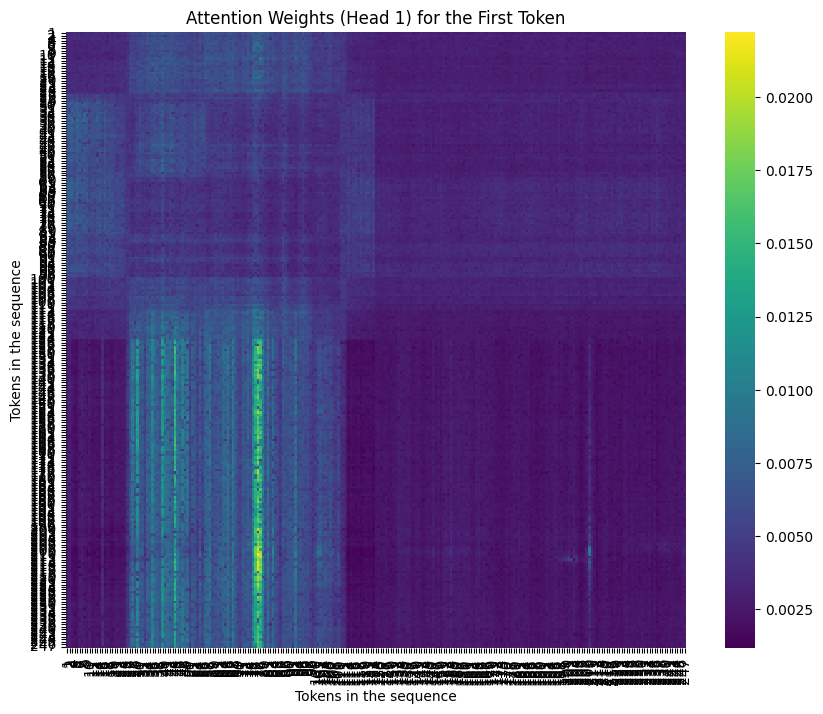

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming attention_weights has the shape [batch_size, num_heads, seq_len, seq_len]
# For simplicity, let's assume you have the attention weights for batch_size=1, num_heads=1

# Select attention weights for the first token (e.g., the first token in the sequence) and first head
# attention_head = attention_weights[2, 0][0].cpu().detach().numpy()  # Convert to numpy for visualization
attention_head = attention_weights.cpu().detach().numpy()  # Convert to numpy for visualization

# Create a heatmap for the attention weights of a specific token
plt.figure(figsize=(10, 8))
sns.heatmap(attention_head, cmap='viridis', xticklabels=range(1, len(attention_head)+1), yticklabels=range(1, len(attention_head)+1))

# Label the axes and show the plot
plt.xlabel("Tokens in the sequence")
plt.ylabel("Tokens in the sequence")
plt.title("Attention Weights (Head 1) for the First Token")
plt.show()


In [14]:
summed_mat = np.sum(attention_head, axis=0)

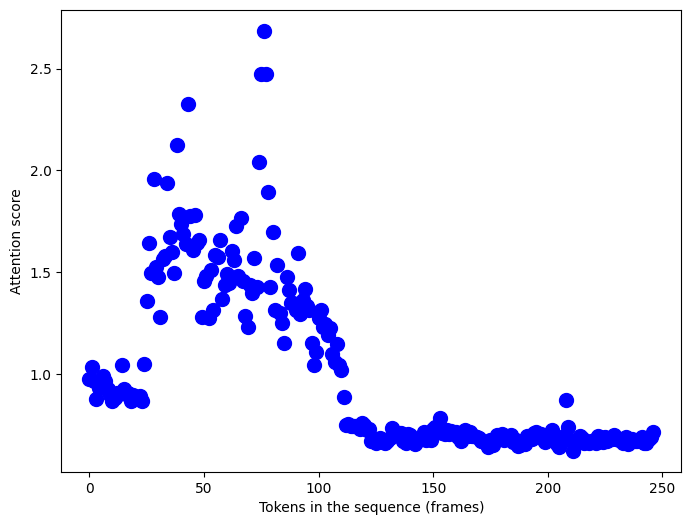

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(range(len(summed_mat)), summed_mat, color="b", s=100, label="Summed values")

plt.xlabel("Tokens in the sequence (frames)")
plt.ylabel("Attention score")
# plt.title("Attention Weights (Head 1) for the First Token")
plt.show()

In [16]:
# dfsf

In [17]:
for batch in iter(test_iter):
                # reactivate training
                # create a Batch object from torchtext batch
                # print(type(batch.signer))
                if batch.signer[0] == "70271.npy":
                    print(batch.signer)
                    batch = Batch(
                        is_train=True,
                        torch_batch=batch,
                        txt_pad_index=txt_pad_index,
                        sgn_dim=feature_size,
                        use_cuda=True,
                        frame_subsampling_ratio=frame_subsampling_ratio,
                        random_frame_subsampling=random_frame_subsampling,
                        random_frame_masking_ratio=random_frame_masking_ratio,
                    )
                    
                    # print(batch.sgn.shape)
                    # if batch.sgn.shape[1] != 247:
                    #    continue     
                    decoder_outputs, gloss_probabilities, attention_weights2 = model(
                    # outputs = model(
                        sgn=batch.sgn,
                        sgn_mask=batch.sgn_mask,
                        sgn_lengths=batch.sgn_lengths,
                        txt_input=batch.txt_input,
                        txt_mask=batch.txt_mask,
                    )

                    break
                


['70271.npy']


/home/bio/anaconda3/envs/slt_env/lib/python3.10/site-packages/torchtext/data/field.py:359: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  var = torch.tensor(arr, dtype=self.dtype, device=device)


In [18]:
if isinstance(attention_weights2, list):
    attention_weights2 = torch.stack(attention_weights2)

attention_weights2 = attention_weights2.sum(dim=(0,1,2))
attention_weights2 = attention_weights2 / 32

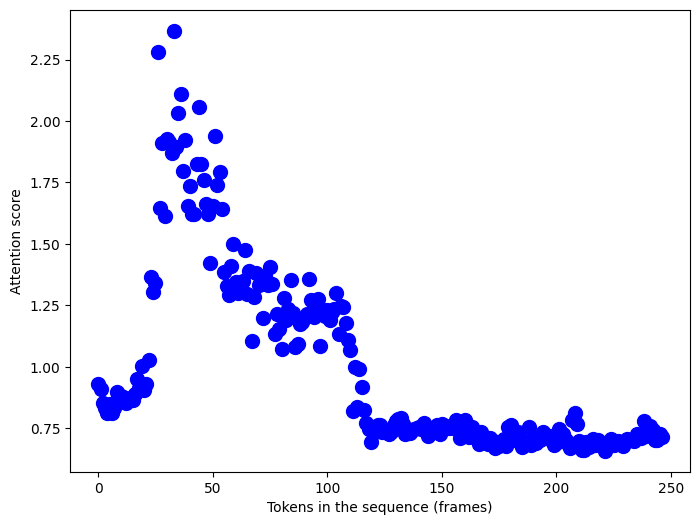

In [19]:
attention_weights2.shape
attention_head2 = attention_weights2.cpu().detach().numpy() 
summed_mat2 = np.sum(attention_head2, axis=0)
plt.figure(figsize=(8, 6))
plt.scatter(range(len(summed_mat2)), summed_mat2, color="b", s=100, label="Summed values")

plt.xlabel("Tokens in the sequence (frames)")
plt.ylabel("Attention score")
# plt.title("Attention Weights (Head 1) for the First Token")
plt.show()

In [20]:
for batch in iter(test_iter):
                # reactivate training
                # create a Batch object from torchtext batch
                # print(type(batch.signer))
                if batch.signer[0] == "70237.npy":
                    print(batch.signer)
                    batch = Batch(
                        is_train=True,
                        torch_batch=batch,
                        txt_pad_index=txt_pad_index,
                        sgn_dim=feature_size,
                        use_cuda=True,
                        frame_subsampling_ratio=frame_subsampling_ratio,
                        random_frame_subsampling=random_frame_subsampling,
                        random_frame_masking_ratio=random_frame_masking_ratio,
                    )
                    
                    # print(batch.sgn.shape)
                    # if batch.sgn.shape[1] != 247:
                    #    continue     
                    decoder_outputs, gloss_probabilities, attention_weights3 = model(
                    # outputs = model(
                        sgn=batch.sgn,
                        sgn_mask=batch.sgn_mask,
                        sgn_lengths=batch.sgn_lengths,
                        txt_input=batch.txt_input,
                        txt_mask=batch.txt_mask,
                    )

                    break
                


['70237.npy']


In [21]:
if isinstance(attention_weights3, list):
    attention_weights3 = torch.stack(attention_weights3)

attention_weights3 = attention_weights3.sum(dim=(0,1,2))
attention_weights3 = attention_weights3 / 32

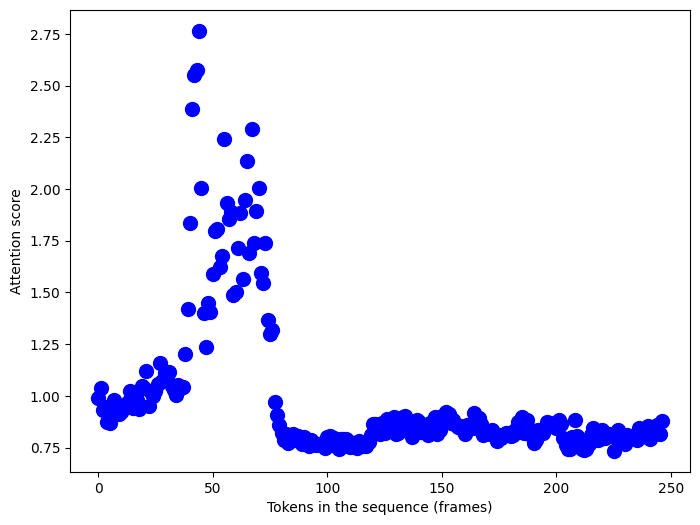

In [22]:
attention_weights3.shape
attention_head3 = attention_weights3.cpu().detach().numpy() 
summed_mat3 = np.sum(attention_head3, axis=0)
plt.figure(figsize=(8, 6))
plt.scatter(range(len(summed_mat3)), summed_mat3, color="b", s=100, label="Summed values")

    # Label the axes and show the plot
plt.xlabel("Tokens in the sequence (frames)")
plt.ylabel("Attention score")
# plt.title("Attention Weights (Head 1) for the First Token")
plt.show()